In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240914

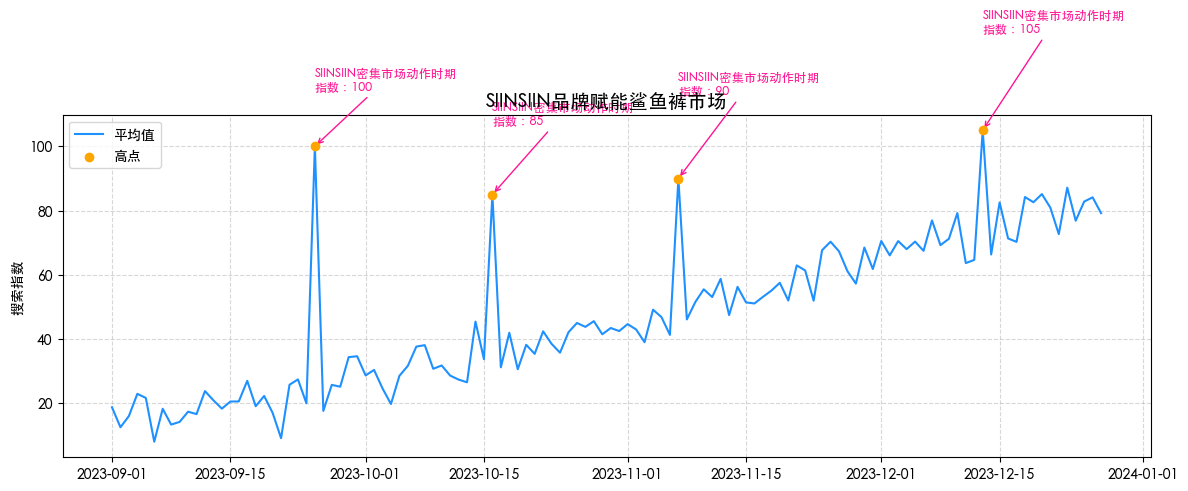

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 构造时间序列
dates = np.arange('2023-09-01', '2023-12-28', dtype='datetime64[D]')
np.random.seed(0)
base = np.linspace(10, 80, len(dates)) + np.random.normal(0, 5, len(dates))

# 人工制造几个高峰模拟“密集市场动作”
spikes = {
    '2023-09-25': 100,
    '2023-10-16': 85,
    '2023-11-07': 90,
    '2023-12-13': 105
}
for date, value in spikes.items():
    idx = np.where(dates == np.datetime64(date))[0][0]
    base[idx] = value

# 创建图表
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, base, label='平均值', color='dodgerblue')

# 添加高点标注点
highlight_dates = list(spikes.keys())
highlight_vals = [spikes[d] for d in highlight_dates]
ax.scatter(highlight_dates, highlight_vals, color='orange', zorder=5, label='高点')

# 添加注释（箭头 + 描述 + 数值）
for i, (date, value) in enumerate(zip(highlight_dates, highlight_vals)):
    ax.annotate("SIINSIIN密集市场动作时期\n指数：" + str(value),
                xy=(np.datetime64(date), value),
                xytext=(0, 40 + i * 10),
                textcoords='offset points',
                arrowprops=dict(arrowstyle="->", color='deeppink'),
                fontsize=9, color='deeppink')

# 样式设置
ax.set_title("SIINSIIN品牌赋能鲨鱼裤市场", fontsize=14)
ax.set_ylabel("搜索指数")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


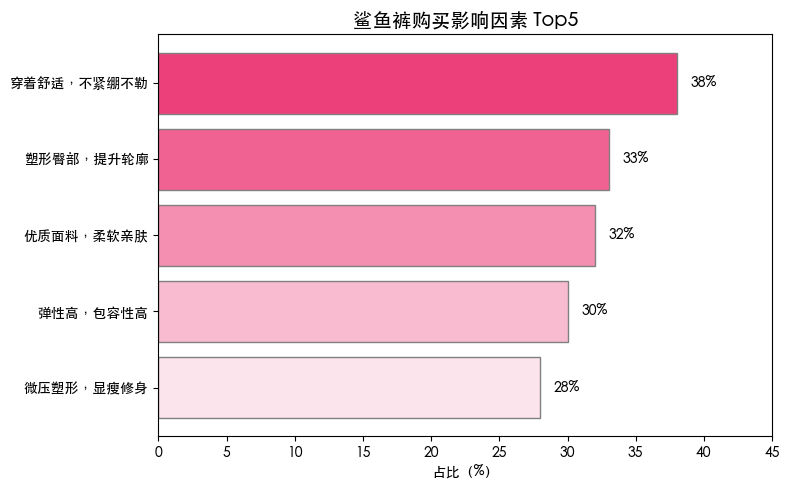

In [3]:
# 图表3：重新绘制横向柱状图，优化颜色方案与标签可视化

import matplotlib.pyplot as plt

factors = [
    "穿着舒适，不紧绷不勒",
    "塑形臀部，提升轮廓",
    "优质面料，柔软亲肤",
    "弹性高，包容性高",
    "微压塑形，显瘦修身"
]
percentages = [38, 33, 32, 30, 28]

colors = ['#ec407a', '#f06292', '#f48fb1', '#f8bbd0', '#fce4ec']  # 渐变粉

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(factors, percentages, color=colors, edgecolor='gray')

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width}%', va='center', fontsize=10)

# 标题与美化
ax.set_title("鲨鱼裤购买影响因素 Top5", fontsize=14)
ax.invert_yaxis()  # 最高的在上方
ax.set_xlim(0, 45)
ax.set_xlabel("占比（%）")
plt.tight_layout()
plt.show()


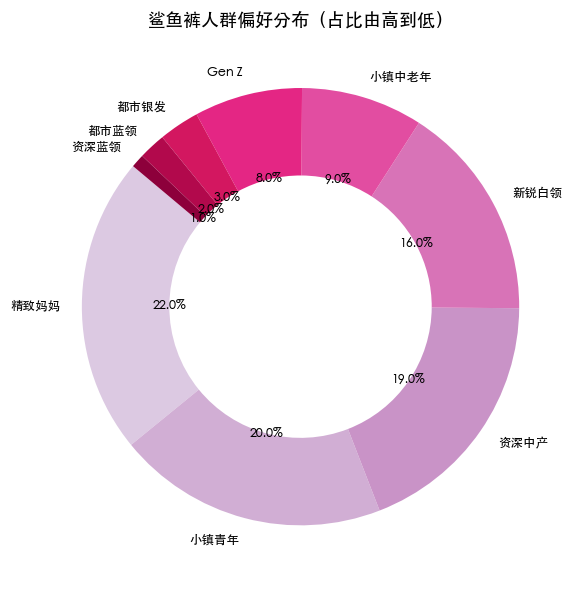

In [4]:
# 图表4（再优化）：在每个扇形区域旁添加中文标签与百分比数值，提升可读性

labels = [
    "精致妈妈", "小镇青年", "资深中产", "新锐白领",
    "小镇中老年", "Gen Z", "都市银发", "都市蓝领", "资深蓝领"
]
sizes = [22, 20, 19, 16, 9, 8, 3, 2, 1]
colors = plt.cm.PuRd(np.linspace(0.2, 0.9, len(labels)))

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4),
    textprops=dict(color="black", fontsize=9)
)

# 标题美化
ax.set_title("鲨鱼裤人群偏好分布（占比由高到低）", fontsize=13)

plt.tight_layout()
plt.show()
